In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bilby
from pycbc.detector import Detector
from scipy.stats import gaussian_kde

/opt/miniconda3/envs/LALSuite_edited/lib/python3.13/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


## Example: Randomly drawn samples

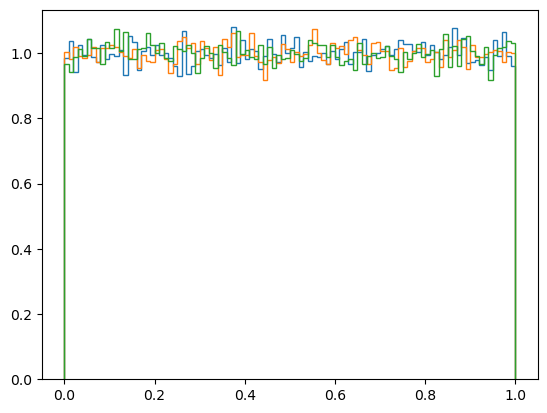

In [2]:
Samples = np.random.uniform(0,1,(100000,3))  # Generating samples
plt.hist(Samples[:,0],bins=100,histtype="step",density=True)
plt.hist(Samples[:,1],bins=100,histtype="step",density=True)
plt.hist(Samples[:,2],bins=100,histtype="step",density=True)
plt.show()

In [3]:
Old_prior = lambda x:x**2
New_prior = lambda x:x

weights = New_prior(Samples[:,0]) / Old_prior(Samples[:,0])   # We wish to reweight the samples using new and old priors. Computing weights here.
idx = np.random.choice(range(Samples.shape[0]), Samples.shape[0], p = weights/weights.sum())  # Sampling indices of original samples, with probabilities p (which we computed using weights). 
Samples_new = Samples[idx,:]

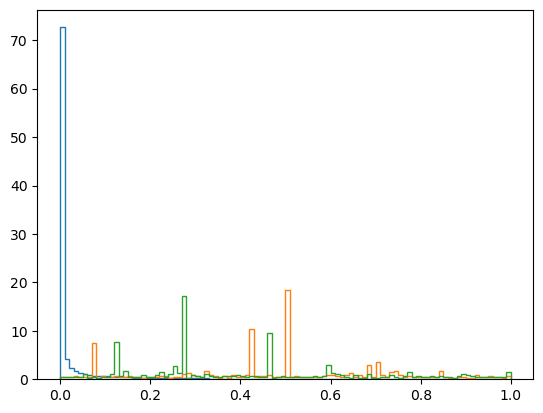

In [4]:
plt.hist(Samples_new[:,0],bins=100,histtype="step",density=True)
plt.hist(Samples_new[:,1],bins=100,histtype="step",density=True)
plt.hist(Samples_new[:,2],bins=100,histtype="step",density=True)
plt.show()

## We now use the same idea to get H1_time priors, given the priors on geocent time, ra and dec.

In [5]:
priors = bilby.gw.prior.CBCPriorDict(
    dict(
        chirp_mass=bilby.core.prior.Uniform(
            minimum=20,
            maximum=40,
            name="chirp_mass",
            latex_label="$\\mathcal{M}$",
        ),
        mass_ratio=bilby.core.prior.Uniform(
            minimum=1 / 6,
            maximum=1.0,
            name="mass_ratio",
            latex_label="$q$",
        ),
        chi_1=bilby.core.prior.Uniform(
            minimum=-0.99,
            maximum=0.99,
            name="chi_1",
            latex_label="$\\chi_1$",
        ),
        chi_2=bilby.core.prior.Uniform(
            minimum=-0.99,
            maximum=0.99,
            name="chi_2",
            latex_label="$\\chi_2$",
        ),
        luminosity_distance=bilby.gw.prior.UniformSourceFrame(
            name="luminosity_distance", minimum=1e1, maximum=500, unit="Mpc"
        ),
        theta_jn=bilby.core.prior.Sine(name="theta_jn"),
        ra=bilby.core.prior.Uniform(
            minimum=0, maximum=2 * np.pi, name="ra", boundary="periodic"
        ),
        dec=bilby.core.prior.Cosine(name="dec"),
        psi=bilby.core.prior.Uniform(
            minimum=0, maximum=np.pi, name="psi", boundary="periodic"
        ),
        phase=bilby.core.prior.Uniform(
            minimum=0, maximum=2 * np.pi, name="phase", boundary="periodic"
        ),
        geocent_time=bilby.core.prior.Uniform(
            1126259642.413 - 0.1,
            1126259642.413 + 0.1,
            name="geocent_time",
            latex_label="$t_c$",
        ),
    )
)

In [6]:
fiducial_parameters = dict(
    mass_1=36.0,
    mass_2=29.0,
    chi_1=0.4,
    chi_2=0.3,
    luminosity_distance=2000.0,
    theta_jn=0.4,
    psi=2.659,
    phase=1.3,
    geocent_time=1126259642.413,
    ra=1.375,
    dec=-1.2108,
)

In [7]:
t_o_delay = t_delay = Detector('H1').time_delay_from_earth_center(right_ascension=fiducial_parameters["ra"], declination=fiducial_parameters["dec"],t_gps=fiducial_parameters["geocent_time"])
fiducial_parameters["H1_time"] = fiducial_parameters["geocent_time"] + t_o_delay
fiducial_parameters["H1_time"]

np.float64(1126259642.4245207)

In [8]:
priors.validate_prior(duration=2, minimum_frequency=20)

True

In [9]:
Samples = priors.sample(int(3e4))

In [10]:
t_delay = Detector('H1').time_delay_from_earth_center(right_ascension=Samples["ra"], declination=Samples["dec"],t_gps=Samples["geocent_time"])
Samples["H1_time"] = Samples["geocent_time"] + t_delay

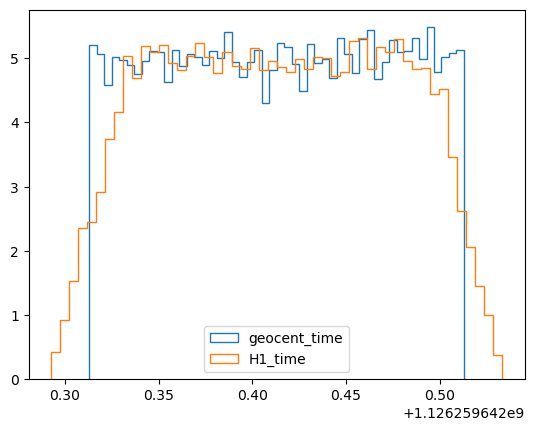

In [11]:
# plt.hist(Samples["ra"],histtype="step",label = "ra",density=True)
# plt.hist(Samples["dec"],histtype="step",label = "dec",density=True)
plt.hist(Samples["geocent_time"],histtype="step",label = "geocent_time",density=True,bins=50)
plt.hist(Samples["H1_time"],histtype="step",label = "H1_time",density=True,bins=50)
plt.legend()
plt.show()

(array([0.08063186, 0.22799354, 0.35086623, 0.44368911, 0.49234627,
        0.48838953, 0.44882218, 0.36049072, 0.22991844, 0.08501635]),
 array([-1.56461731, -1.25291257, -0.94120783, -0.62950308, -0.31779834,
        -0.0060936 ,  0.30561114,  0.61731588,  0.92902062,  1.24072536,
         1.5524301 ]),
 [<matplotlib.patches.Polygon at 0x167ad0190>])

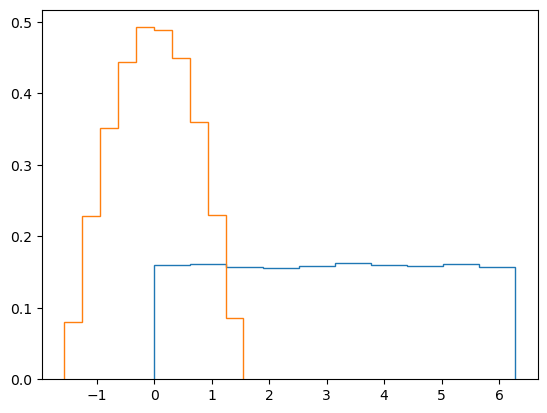

In [12]:
plt.hist(Samples["ra"],histtype="step",label = "ra",density=True)
plt.hist(Samples["dec"],histtype="step",label = "dec",density=True)

In [13]:
New_prior_H1_time = bilby.core.prior.Uniform(
            fiducial_parameters["H1_time"] - 0.1,
            fiducial_parameters["H1_time"] + 0.1,
            name="H1_time",
            latex_label="$t_{H1}$",
            unit=None,
            boundary=None,
        )

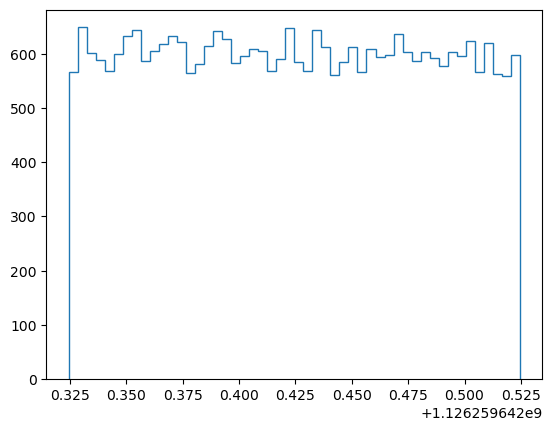

In [14]:
_ = plt.hist(New_prior_H1_time.sample(len(Samples["H1_time"])),bins=50,histtype="step")

In [15]:
kde = gaussian_kde(Samples["H1_time"])
q_x = kde(Samples["H1_time"])  # Old P
p_x = 1/(Samples["H1_time"].max() - Samples["H1_time"].min())  # new P

In [16]:
w = p_x/q_x
idx = np.random.choice(range(len(Samples["H1_time"])),
                       len(Samples["H1_time"]),
                       p = w/w.sum())

In [17]:
Samples_new = {}
for k in Samples.keys():
    Samples_new[k] = Samples[k][idx]

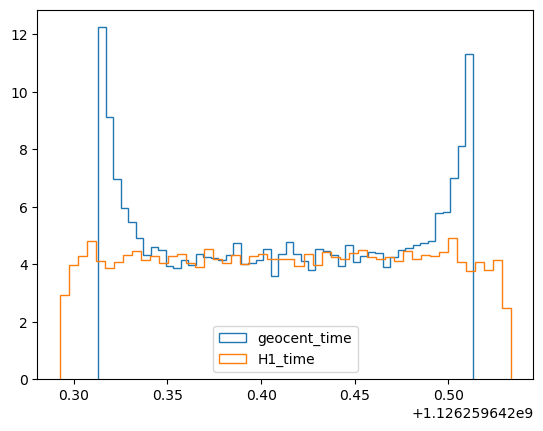

In [18]:
plt.hist(Samples_new["geocent_time"],histtype="step",label = "geocent_time",density=True,bins=50)
plt.hist(Samples_new["H1_time"],histtype="step",label = "H1_time",density=True,bins=50)
plt.legend()
plt.show()

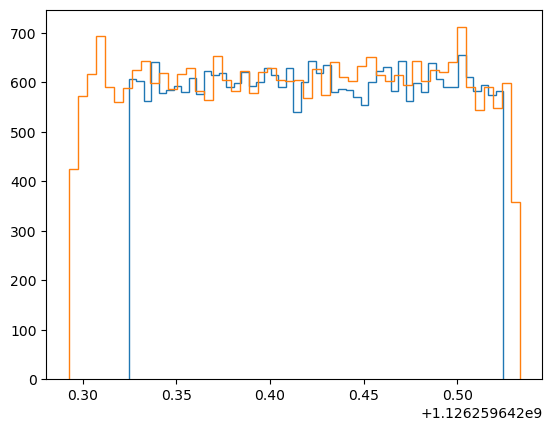

In [19]:
plt.hist(New_prior_H1_time.sample(len(Samples["H1_time"])),bins=50,histtype="step")
plt.hist(Samples_new["H1_time"],bins=50,histtype="step")
plt.show()

## Now we reweight the samples

In [20]:
Samples2 = {}
Samples2["geocent_time"] = np.random.normal(loc = fiducial_parameters["geocent_time"],scale=0.03,size=30000)  # What if size here is different than the size i took when reweighting the priors?
Samples2["ra"] = (Samples["ra"].copy())
Samples2["dec"] = (Samples["dec"].copy())

In [21]:
t_delay = Detector('H1').time_delay_from_earth_center(right_ascension=Samples2["ra"], declination=Samples2["dec"],t_gps=Samples2["geocent_time"])
Samples2["H1_time"] = Samples2["geocent_time"] + t_delay

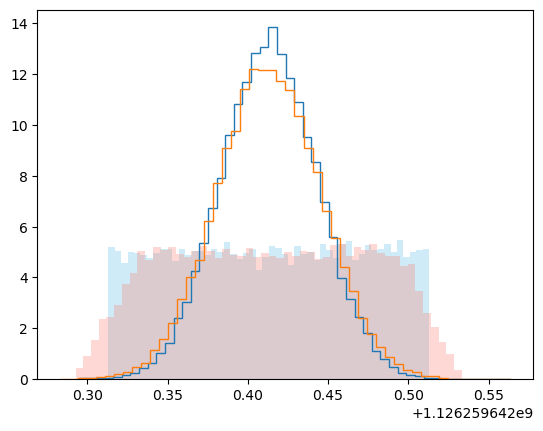

In [22]:
plt.hist(Samples2["geocent_time"],bins=50,histtype="step",label="geocent_time",density=True)
plt.hist(Samples2["H1_time"],bins=50,histtype="step",label = "H1_time",density=True)
plt.hist(Samples["geocent_time"],alpha=0.4,label = "geocent_time prior",density=True,bins=50,color="skyblue")
plt.hist(Samples["H1_time"],alpha=0.3,label = "H1_time prior",density=True,bins=50,color = "salmon")
plt.show()

In [23]:
Samples_new2 = {}
for k in Samples2.keys():
    Samples_new2[k] = Samples2[k][idx]

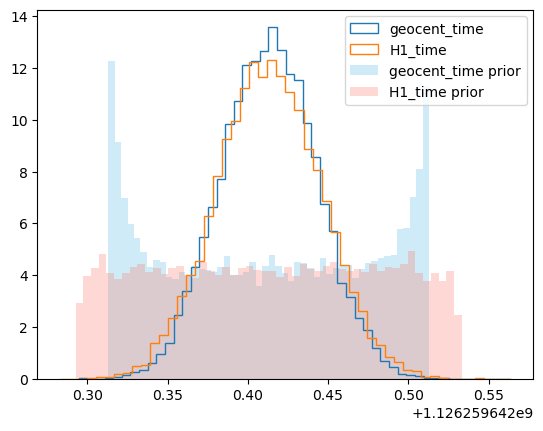

In [24]:
plt.hist(Samples_new2["geocent_time"],histtype="step",label = "geocent_time",density=True,bins=50)
plt.hist(Samples_new2["H1_time"],histtype="step",label = "H1_time",density=True,bins=50)
plt.hist(Samples_new["geocent_time"],alpha=0.4,label = "geocent_time prior",density=True,bins=50,color="skyblue")
plt.hist(Samples_new["H1_time"],alpha=0.3,label = "H1_time prior",density=True,bins=50,color = "salmon")
plt.legend()
plt.show()